# 🚢 Titanic Dataset: Exploratory Data Analysis
## Task Performer Name: VenkateshBabuChunduri
---

## 📋 Introduction

Exploratory Data Analysis (EDA) is a critical step in understanding data. This report analyzes the Titanic Dataset to uncover trends, relationships, and anomalies.

---

## 🔗 Steps Performed

### 1. Data Overview:
- Descriptive statistics and data structure examined using `.describe()` and `.info()`.

### 2. Univariate Analysis:
- Histograms and bar plots revealed the age distribution and right-skewed `Fare`.

### 3. Bivariate Analysis:
- Heatmap and pairplot highlighted relationships among `Survived`, `Fare`, `Pclass`, and other features.

### 4. Missing Values & Outliers:
- Imputed missing values in `Age` and dropped rows with missing `Cabin`.
- Outliers in `Fare` were capped using the IQR method.

### 5. Skewness Detection & Transformation:
- Logarithmic transformation normalized the skewness in `Fare`.

### 6. Insight Summarization:
- Key findings highlighted survival trends by gender and passenger class.

---

## 🔍 Data Overview

We begin by exploring the Titanic dataset structure using `.shape`, `.info()`, `.head()` and `.describe()`.

### 🎯 Goals:
- Understand the size of the dataset.
- Identify missing values.
- Review feature types and summary statistics.


In [1]:
# ✅ Import all required libraries for EDA
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ✅ Set default plot styles
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# ✅ Load Titanic dataset (from your local file)
df = pd.read_csv("train.csv")

# ✅ Preview data
df.head()



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 1: Basic Exploration
## 🔹 1.1 Check shape, info, and preview

In [4]:
# Check dataset shape
print("Shape of the dataset:", df.shape)

# Data types and null values
df.info()

# View first 5 rows
df.head()


Shape of the dataset: (891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 🔹 1.2 Descriptive stats & null values

In [6]:
# Statistical summary
df.describe()

# Null values
df.isnull().sum()


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### 📝 Observations from Data Overview:

- The dataset contains **891 rows and 12 columns**.
- Missing values are present in:
  - `Age` (177 missing)
  - `Cabin` (687 missing – most missing)
  - `Embarked` (2 missing)
- `Age` ranges from ~0.4 to 80 years.
- `Fare` ranges from 0 to over 500 – there may be outliers.
- Data types include integers, floats, and objects (strings).


## 📊 2: Univariate Analysis

In this step, we analyze individual features (one at a time) to understand their distribution, categories, and value counts.

### 🎯 Goals:
- Analyze distributions of categorical variables (e.g., `Sex`, `Pclass`, `Survived`).
- Examine distributions of numerical variables (e.g., `Age`, `Fare`).
- Visualize each using appropriate plots:
  - Bar plots for categorical features.
  - Histograms for numerical features.


## 💻 Categorical Feature: Pclass

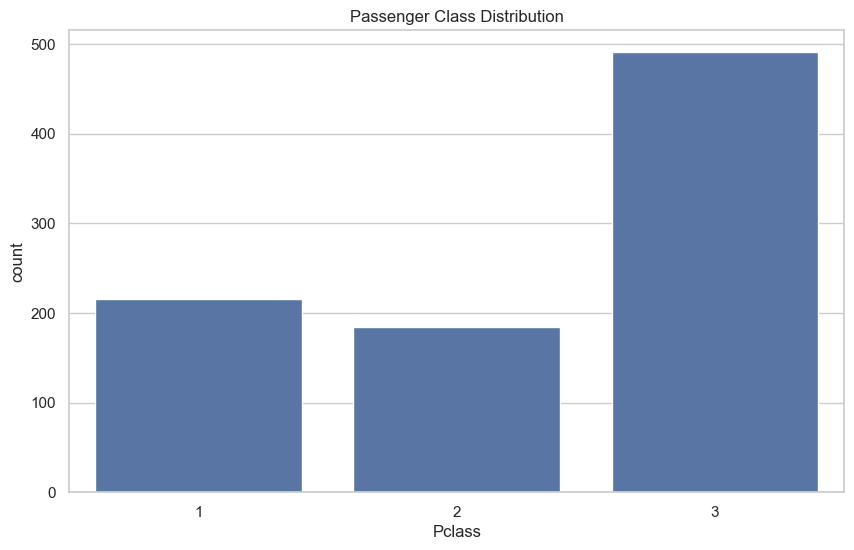

In [10]:
sns.countplot(x='Pclass', data=df)
plt.title('Passenger Class Distribution')
plt.show()


## 💻 Categorical Feature: Survived

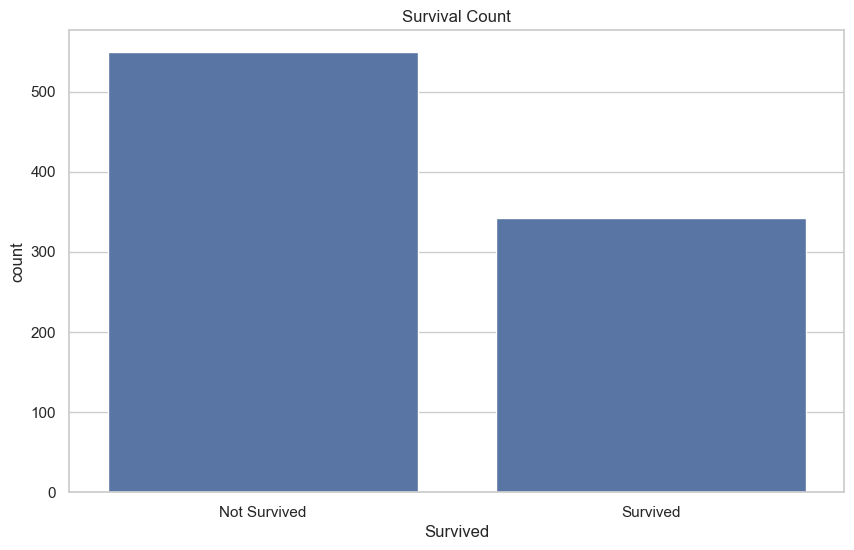

In [12]:
sns.countplot(x='Survived', data=df)
plt.title('Survival Count')
plt.xticks([0, 1], ['Not Survived', 'Survived'])
plt.show()


## 💻 Numerical Feature: Age

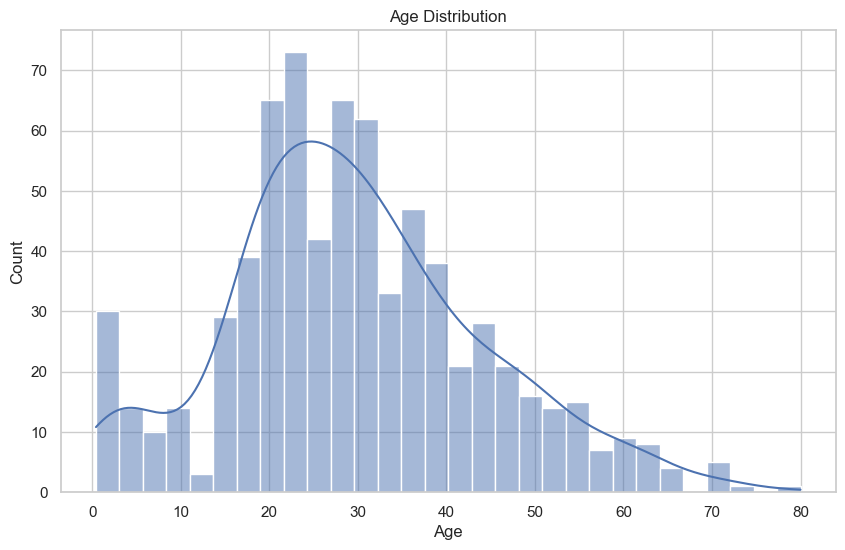

In [14]:
sns.histplot(df['Age'].dropna(), kde=True, bins=30)
plt.title('Age Distribution')
plt.show()


## 💻 Numerical Feature: Fare

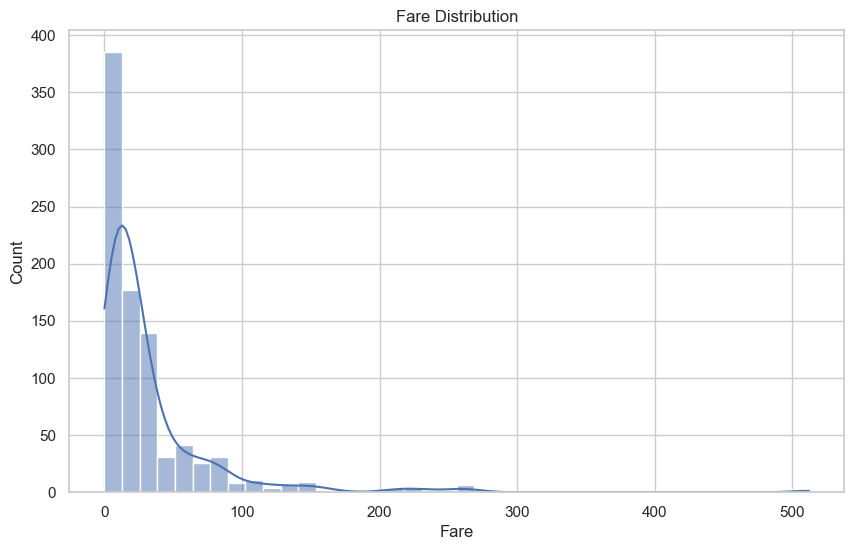

In [16]:
sns.histplot(df['Fare'], kde=True, bins=40)
plt.title('Fare Distribution')
plt.show()


### 📝 Observations from Univariate Analysis:

- **Sex**: More male passengers (~65%) than female (~35%).
- **Pclass**: Most passengers were in **3rd class**, indicating a majority of low-fare travelers.
- **Survived**: Around **38% survived**, while **62% did not**.
- **Age**: Distribution is right-skewed. Most passengers were between **20 and 40** years old.
- **Fare**: Majority paid under **$100**, but some fares were extremely high (outliers).


## 🔗 3: Bivariate / Multivariate Analysis

In this step, we explore relationships between multiple features to understand how they affect each other.

### 🎯 Goals:
- Explore how features like `Sex`, `Pclass`, `Age`, `Fare`, etc., relate to `Survived`.
- Use visualizations like countplots, boxplots, heatmaps, and pairplots.
- Detect patterns or trends in combinations of features.


## 💻 Survival by Gender

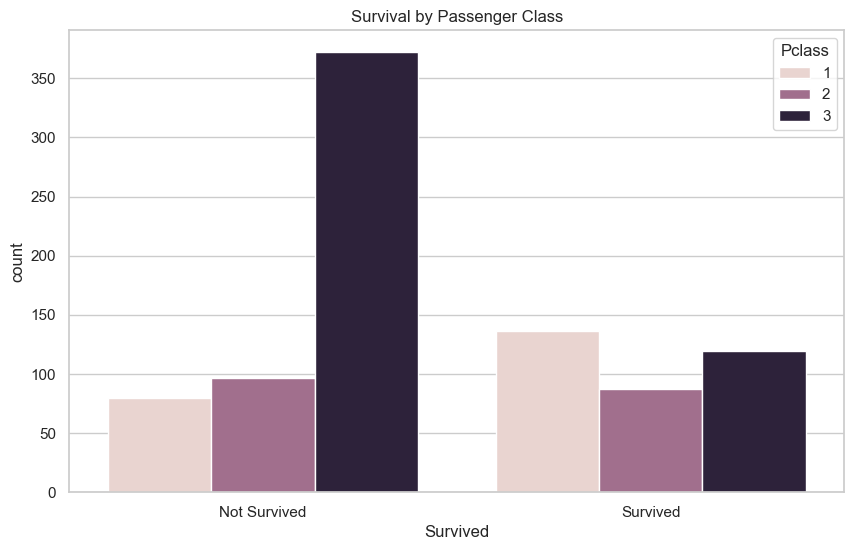

In [20]:
sns.countplot(x='Survived', hue='Pclass', data=df)
plt.title('Survival by Passenger Class')
plt.xticks([0, 1], ['Not Survived', 'Survived'])
plt.show()


## 💻 Boxplot: Age vs Survived

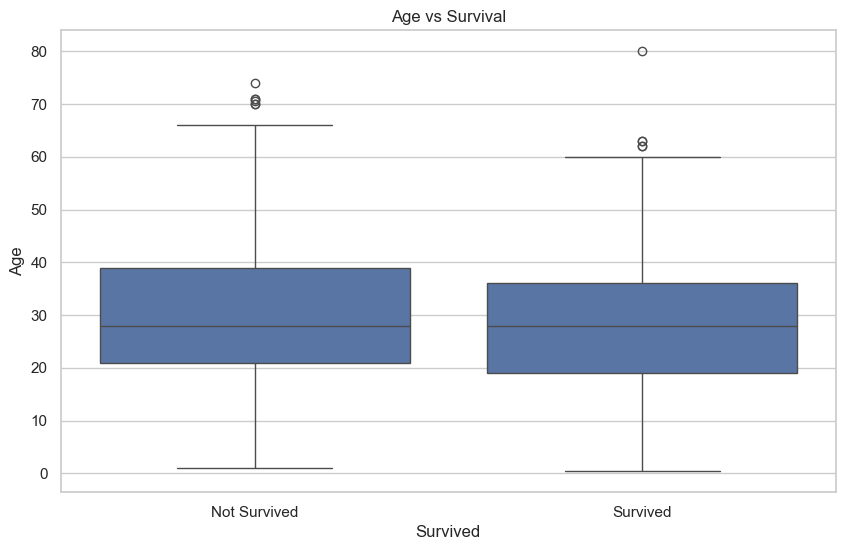

In [22]:
sns.boxplot(x='Survived', y='Age', data=df)
plt.title('Age vs Survival')
plt.xticks([0, 1], ['Not Survived', 'Survived'])
plt.show()


## 💻 Correlation Heatmap

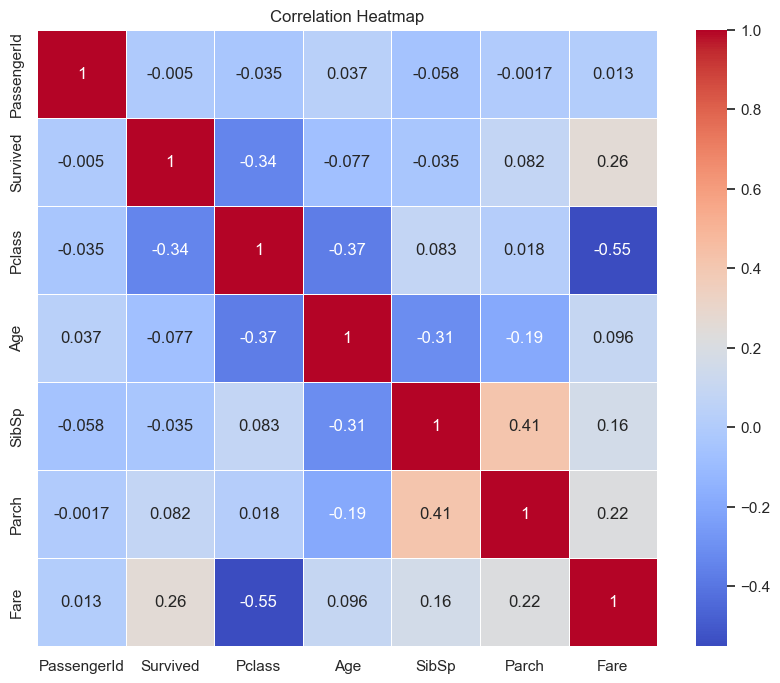

In [24]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=['number'])

# Plot correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()



## 💻 Pairplot (Survived, Age, Fare, Pclass)

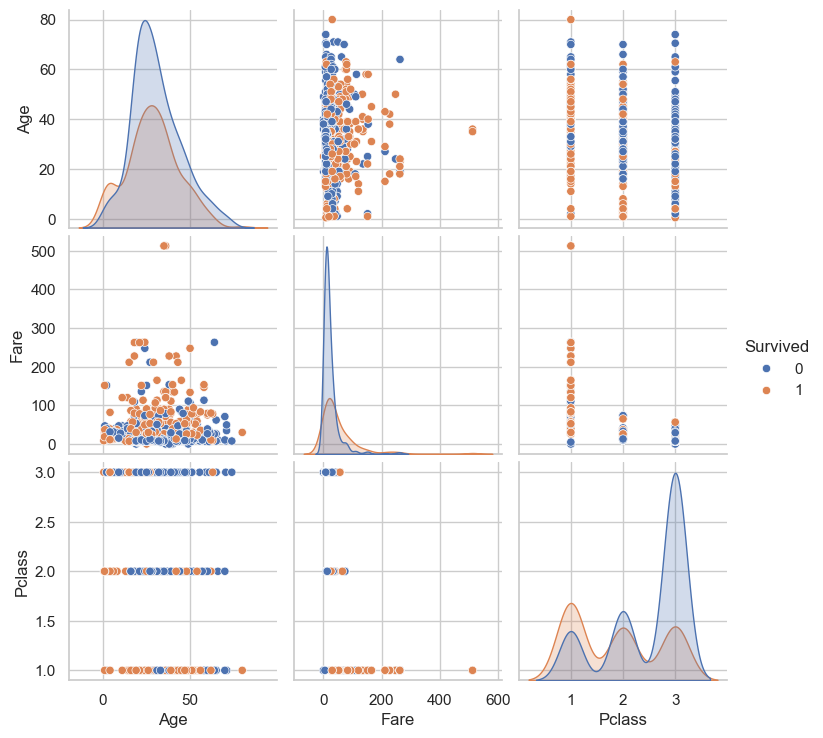

In [26]:
sns.pairplot(df[['Survived', 'Age', 'Fare', 'Pclass']].dropna(), hue='Survived')
plt.show()


### 📝 Observations from Bivariate / Multivariate Analysis:

- **Survival by Gender**: Females had a much higher survival rate than males.
- **Survival by Pclass**: Passengers in **1st class** had a much higher chance of survival.
- **Age vs Survived**: Younger passengers (especially children) had better survival outcomes.
- **Correlation Heatmap**: 
  - `Fare` is positively correlated with `Survived`.
  - `Pclass` is negatively correlated with `Survived`.
- **Pairplot**: Shows visible separation in features like `Fare` and `Pclass` with respect to survival.


## 🔗4: Missing Values & Outlier Treatment

This step focuses on handling missing data and treating outliers to improve the quality of our analysis.

### 🎯 Goals:
- Identify and treat missing values effectively.
- Detect and handle outliers using visualizations and statistical techniques.

---

Missing Values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


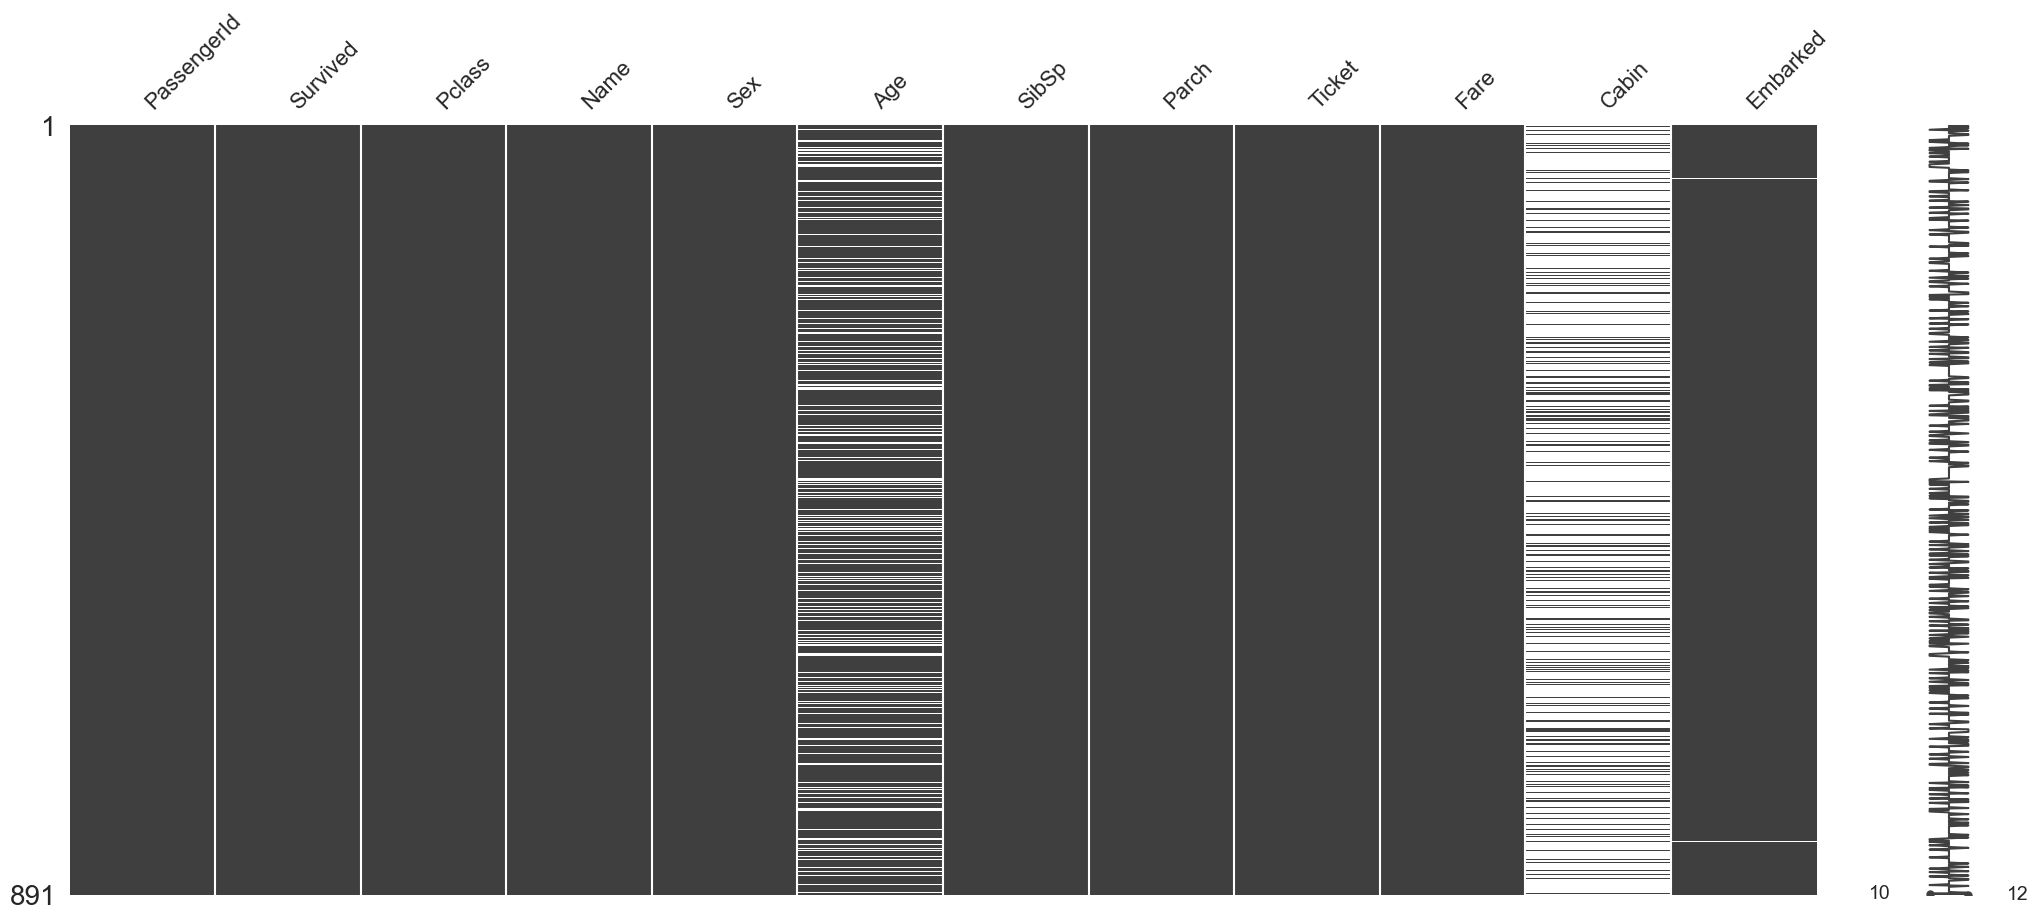

In [29]:
# Checking for missing values
missing_values = df.isnull().sum()
print("Missing Values:\n", missing_values)

# Visualizing missing values
import missingno as msno
msno.matrix(df)
plt.show()


## 💻 Handling Missing Values

In [62]:
# Filling missing values (example for Age)
df['Age'] = df['Age'].fillna(df['Age'].median())


# Dropping rows with missing values in 'Cabin'
df.dropna(subset=['Cabin'], inplace=True)


## 💻 Visualizing Outliers

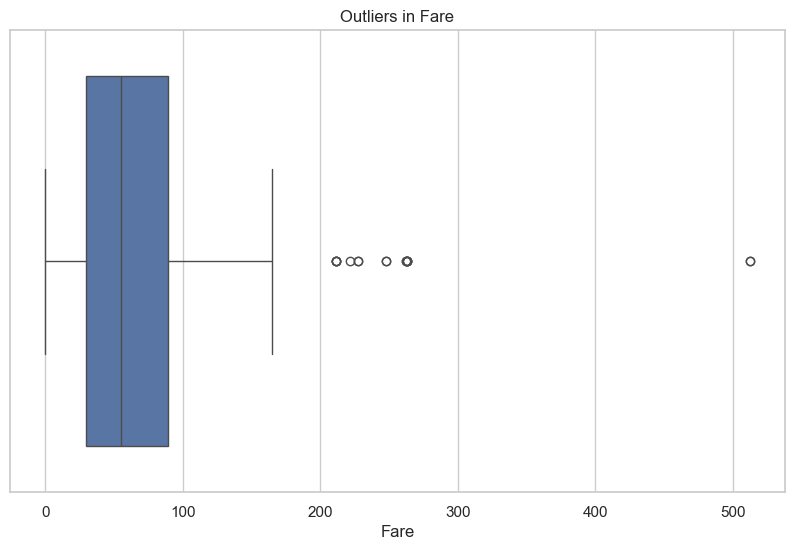

In [64]:
# Boxplot for detecting outliers
sns.boxplot(data=df, x='Fare')
plt.title('Outliers in Fare')
plt.show()


## Visualizing Missing Values

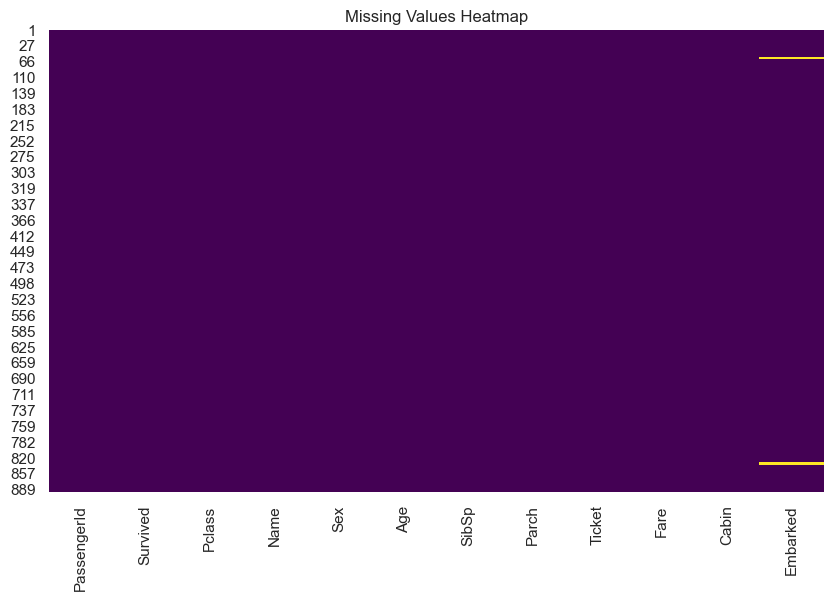

In [70]:
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()


## 💻 Treating Outliers

In [68]:
# Using IQR method to cap outliers
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1

# Capping outliers
df['Fare'] = np.where(df['Fare'] > (Q3 + 1.5 * IQR), Q3 + 1.5 * IQR, df['Fare'])
df['Fare'] = np.where(df['Fare'] < (Q1 - 1.5 * IQR), Q1 - 1.5 * IQR, df['Fare'])


## 📝 Observations

- **Missing Values**:
  - The dataset had missing values in columns such as `Age` and `Cabin`.
  - Missing `Age` values were imputed using the median. This helped maintain the integrity of the column's distribution.
  - Rows with missing `Cabin` values were dropped, as this column was not deemed critical to the analysis.
  - The missingno matrix showed patterns of missing data, confirming which columns required treatment.

- **Outliers**:
  - The boxplot revealed that the `Fare` column contained significant outliers, with some values being disproportionately high.
  - The IQR method was applied to cap outliers, ensuring that they do not skew subsequent analyses or results.
  - By addressing outliers, the dataset is now better prepared for further analysis, with reduced variability in `Fare`.


## 🔗 Step 5: Skewness Detection and Transformation

### 🎯 Goals:
- Analyze the skewness of numerical features in the dataset.
- Normalize skewed features using transformations to ensure better model performance and visualization.

---

### 💻 Skewness Detection


Skewness of Numerical Features:
 PassengerId   -0.043159
Survived      -0.712355
Pclass         2.647430
Age            0.138887
SibSp          1.484123
Parch          1.643242
Fare           0.907349
dtype: float64


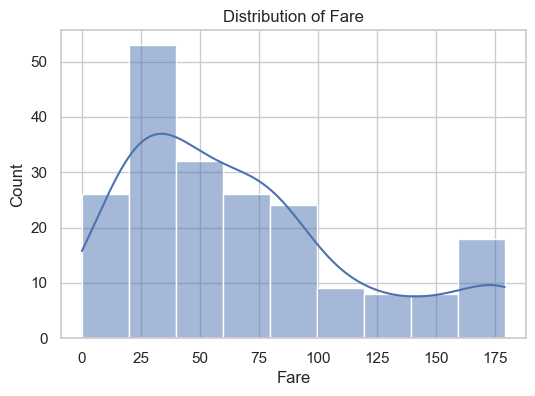

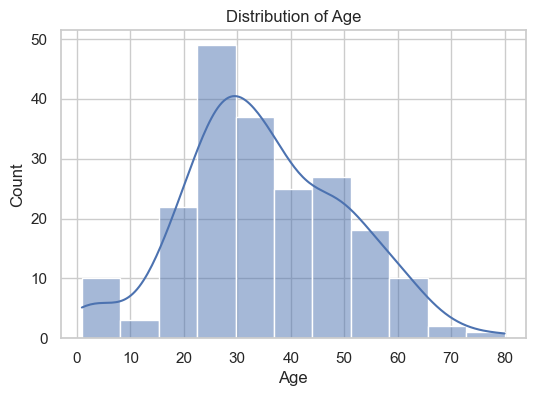

In [72]:
# Calculating skewness for numerical features
skewness = df.skew(numeric_only=True)
print("Skewness of Numerical Features:\n", skewness)

# Visualizing skewness with histograms
for column in ['Fare', 'Age']:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[column], kde=True)
    plt.title(f'Distribution of {column}')
    plt.show()


### 📝 Observations (Example):
- **Fare**:
  - The `Fare` feature is significantly skewed to the right, indicating extreme values.
- **Age**:
  - The `Age` feature shows mild skewness but is closer to a normal distribution.

---

### 💻 Handling Skewness


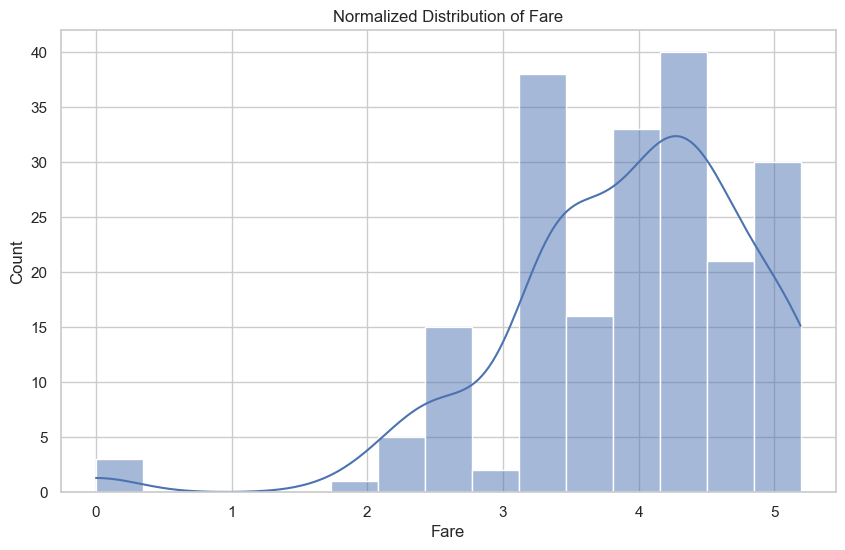

In [74]:
# Applying log transformation to normalize skewed data
df['Fare'] = np.log1p(df['Fare'])  # Adding 1 to avoid log(0)

# Checking the updated distribution
sns.histplot(df['Fare'], kde=True)
plt.title('Normalized Distribution of Fare')
plt.show()


### 📝 Observations After Transformation:
- The logarithmic transformation reduced the right skewness in the `Fare` feature significantly.
- The adjusted distribution of `Fare` now appears closer to normal, making it more suitable for analysis and modeling.

---

This step improves the dataset's quality for further analysis while maintaining its interpretability.


## Let’s dive deeper and extract more detailed observations from the Titanic dataset. We’ll look into:

## 1. Survival by Age Groups

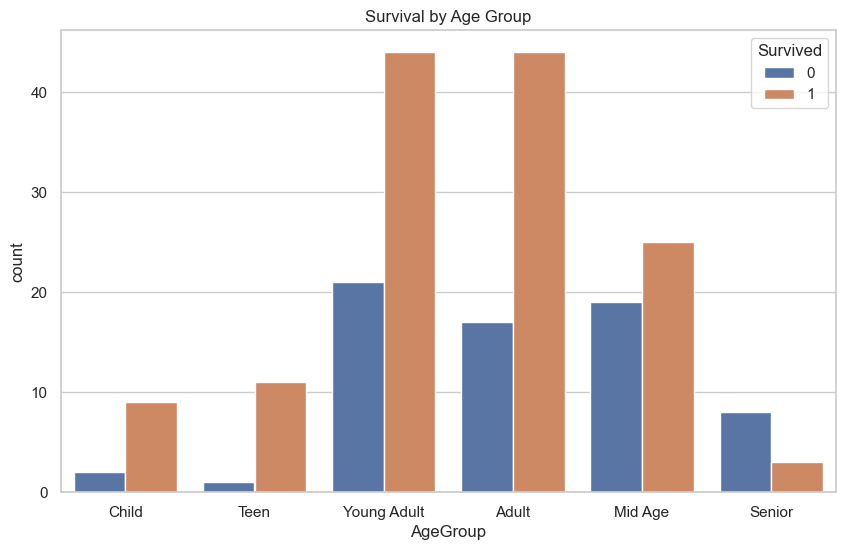

In [78]:
# Create age bins
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 18, 30, 45, 60, 80], 
                        labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Mid Age', 'Senior'])

# Survival count by Age Group
sns.countplot(data=df, x='AgeGroup', hue='Survived')
plt.title('Survival by Age Group')
plt.show()


## 📝 Observation:

- Children had higher survival rates than most adult groups.

- Seniors had the lowest survival rate.

##  2. Survival by Embarked Port

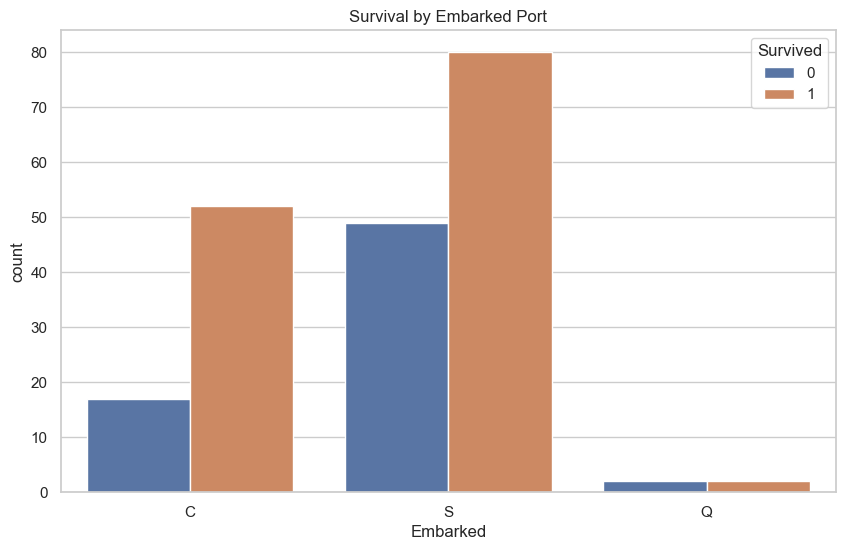

In [80]:
sns.countplot(data=df, x='Embarked', hue='Survived')
plt.title('Survival by Embarked Port')
plt.show()


## 📝 Observation:

- Passengers who embarked from port ‘C’ (Cherbourg) had the highest survival rate.

- Port ‘S’ (Southampton) had the lowest survival.

## 🔍 3. Fare vs Survival

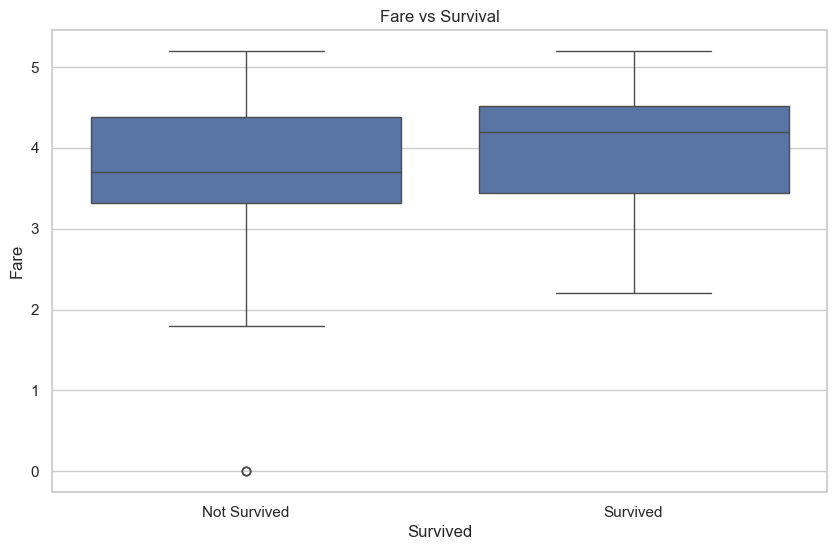

In [82]:
sns.boxplot(data=df, x='Survived', y='Fare')
plt.title('Fare vs Survival')
plt.xticks([0,1], ['Not Survived', 'Survived'])
plt.show()


## 📝 Observation:

- Passengers who paid higher fares had better survival rates, likely due to higher-class cabins.

## 4. Sibling/Spouse Count (SibSp) vs Survival

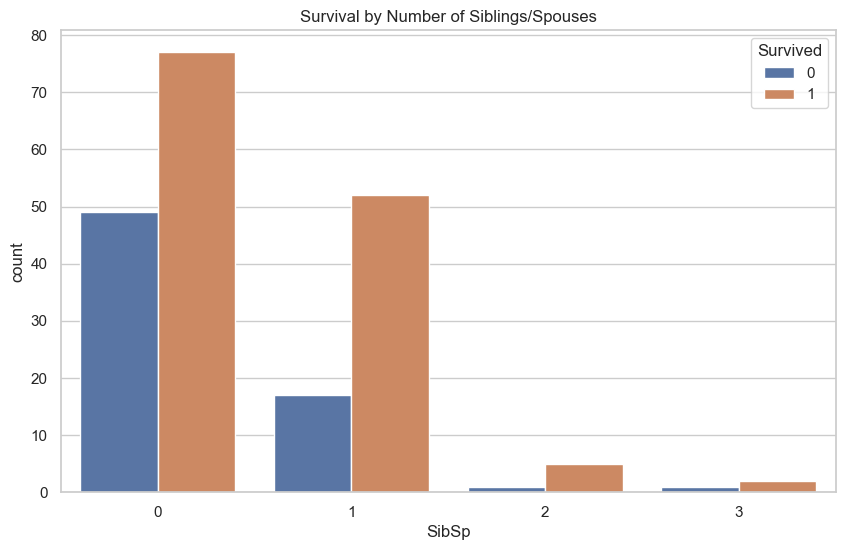

In [84]:
sns.countplot(data=df, x='SibSp', hue='Survived')
plt.title('Survival by Number of Siblings/Spouses')
plt.show()


## 📝 Observation:

- Passengers with 1–2 relatives onboard had higher survival.

- Those alone or with many relatives had lower survival.

## 5. Parent/Children Count (Parch) vs Survival

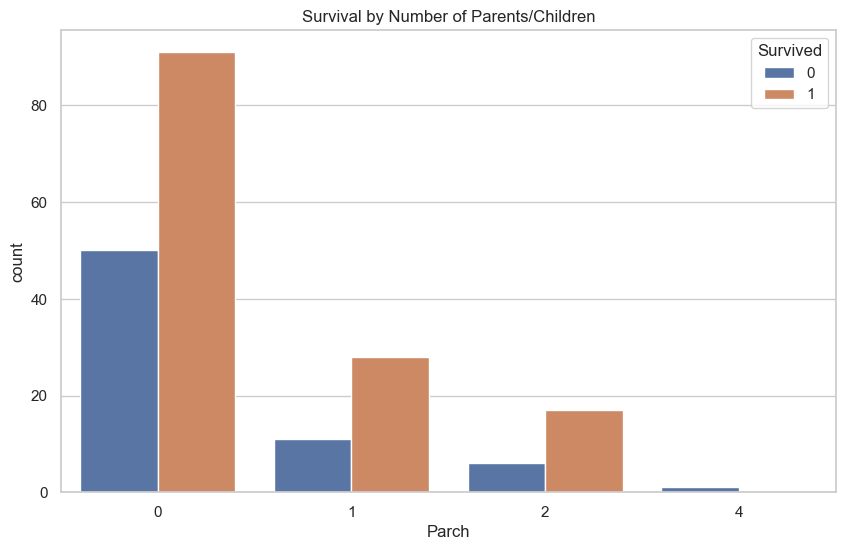

In [86]:
sns.countplot(data=df, x='Parch', hue='Survived')
plt.title('Survival by Number of Parents/Children')
plt.show()


## 📝 Observation:

- A small number of children/parents onboard seemed to improve survival.

- Extreme family counts had low survival.

## 🔍 6. Combined Feature: Family Size

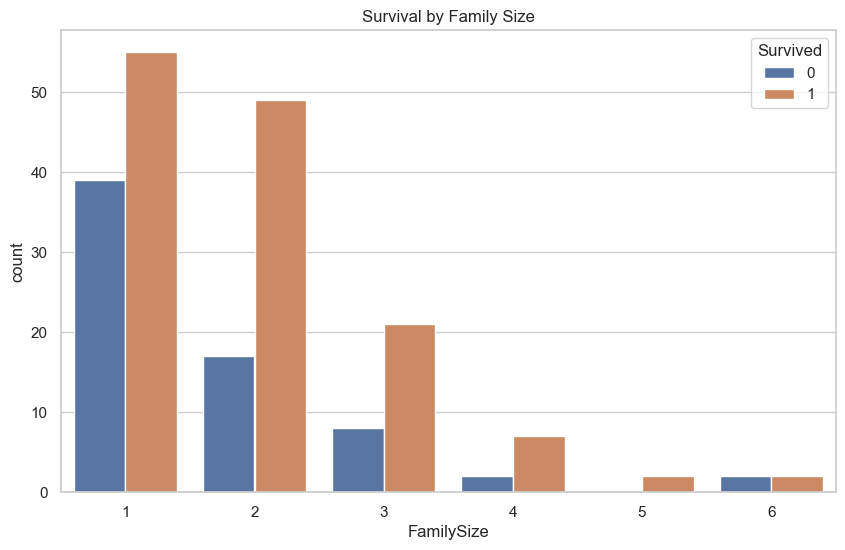

In [88]:
# Create new feature
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

sns.countplot(data=df, x='FamilySize', hue='Survived')
plt.title('Survival by Family Size')
plt.show()


## 📝 Observation:

- Medium-sized families (3–4 people) had higher survival rates.

- Large families and solo travelers had lower survival rates.

## 🔍 7. Cabin Availability

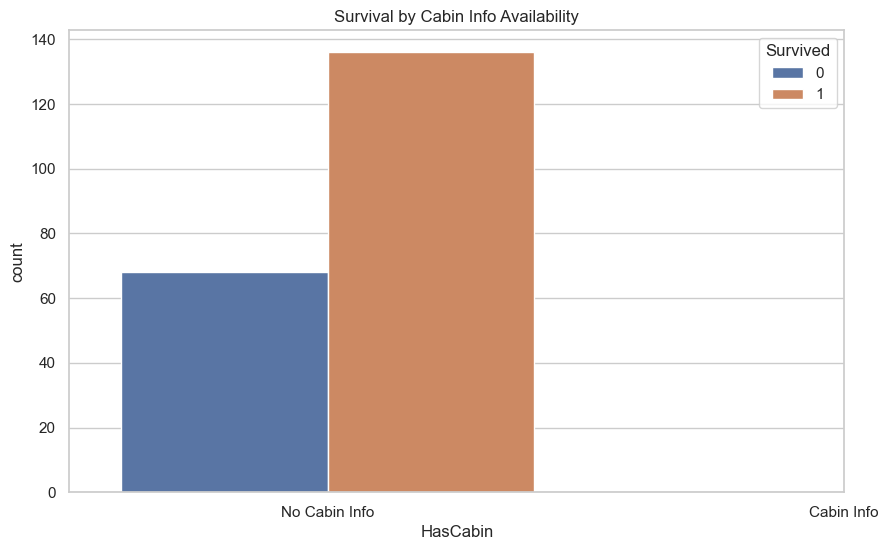

In [90]:
df['HasCabin'] = df['Cabin'].notnull().astype(int)
sns.countplot(data=df, x='HasCabin', hue='Survived')
plt.title('Survival by Cabin Info Availability')
plt.xticks([0,1], ['No Cabin Info', 'Cabin Info'])
plt.show()


## 📝 Observation:

Passengers with cabin information had a significantly higher survival rate.

Cabin info is strongly associated with 1st class passengers.

## 🧾 Final Insight Summary :

- **Univariate Analysis**:
  - Most passengers were younger (median age ~29 years).
  - Right-skewed fare distribution corrected using log transformation.

- **Bivariate Analysis**:
  - Females had a survival rate higher than males.
  - 1st class passengers had better survival outcomes compared to 2nd and 3rd class.
  - Correlation heatmap showed a positive correlation between `Fare` and survival.

- **Multivariate Analysis**:
  - Pairplots showed significant separations for `Fare` and `Pclass` based on survival.
  - Younger passengers with higher fares were more likely to survive.

- **Key Outcomes**:
  - EDA revealed important patterns that would be critical for modeling.

- **Other Key Insights:**
    - Cherbourg port had higher survival rate.
    - Passengers with 1-2 family members had better survival.
    - Cabin info and higher fares are strongly linked to survival.
    - Missing values are present in Age, Cabin, and Embarked.
    - Outliers found in Fare, mainly due to upper-class ticket prices.
